# **1. Setup & Libraries**

In [1]:
!pip install torch

In [2]:
import os, json, random, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, roc_auc_score

In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Not running in Colab — skipping Drive mount.")

Mounted at /content/drive


# **2. Load Dataset**

In [ ]:
# file_path = r"C:\Users\User\Documents\Data\Final processed 3-hourly rainfall data with missing value.csv"
# df_rain = pd.read_csv(file_path)
# df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121051,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2121052,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2121053,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2121054,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


In [5]:
file_path = "/content/drive/MyDrive/Rainfall/Data/Final processed 3-hourly rainfall data with missing value.csv"
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121051,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2121052,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2121053,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2121054,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


In [6]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2074299,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2074300,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2074301,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2074302,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


# **Hyperparameter Training**

In [ ]:
# ============================================================
# BASELINE: True DeepAR (Gaussian Autoregressive RNN)
# + Hyperparameter Tuning (resume-safe)
#
# DeepAR Strict Methodological Implementations:
#   1. Per-Series Scaling (v_i) properly masked in the target domain.
#   2. Pure Teacher Forcing during training.
#   3. Monte Carlo Trajectory Sampling (S=50) during inference.
#   4. Empirical Quantiles derived from the MC paths.
#   5. Station Embeddings fused into both Decoder and Risk Heads.
# ============================================================

import os, json, random, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SAVE_DIR =r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\Baselines\DeepAR\Tuning_v1"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# 1) Utilities & Metrics
# ============================================================
class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.where(np.nanstd(X, axis=0) < self.eps, 1.0, np.nanstd(X, axis=0))
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        return (loss * mask).sum() / mask.sum().clamp_min(1.0)
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = [pinball_loss(y_hat[..., k], y_true, q, mask) for k, q in enumerate(quantiles)]
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        return (loss * mask).sum() / mask.sum().clamp_min(1.0)
    return loss.mean()

def compute_pos_weight(labels, masks):
    pos = (labels * masks).sum().item()
    neg = masks.sum().item() - pos
    if pos < 1: return 1.0
    return float(np.clip((neg + 1e-6) / (pos + 1e-6), 1.0, 30.0))

def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=pos_weight)
    return (loss * mask).sum() / mask.sum().clamp_min(1.0)

def safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {"n_valid": int(valid.sum()), "pr_auc": np.nan, "roc_auc": np.nan, "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds}}
    p, y = probs[valid], y_true[valid]
    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try: roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except: roc_auc = np.nan
    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP, FP, FN = ((yhat==1)&(y==1)).sum(), ((yhat==1)&(y==0)).sum(), ((yhat==0)&(y==1)).sum()
        by_thr[thr] = {"POD": float(safe_div(TP, TP + FN)), "FAR": float(safe_div(FP, TP + FP)), "CSI": float(safe_div(TP, TP + FP + FN))}
    return {"n_valid": int(valid.sum()), "pr_auc": float(pr_auc), "roc_auc": float(roc_auc), "by_thr": by_thr}

# ============================================================
# 2) Preprocessing
# ============================================================
def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    df["DR_sin"] = np.sin(np.deg2rad(df["DR"].astype(np.float32).to_numpy()))
    df["DR_cos"] = np.cos(np.deg2rad(df["DR"].astype(np.float32).to_numpy()))

    stations = df[["StationID", "Latitude", "Longitude"]].drop_duplicates().sort_values("StationID").reset_index(drop=True)
    N = len(stations)
    times = np.sort(df["Datetime"].unique())
    T = len(times)

    full_index = pd.MultiIndex.from_product([times, stations["StationID"].values], names=["Datetime", "StationID"])
    meteo_cols = ["DewPointTemperature", "StationLevelPressure", "SP", "Humidity", "Rainfall", "DR_sin", "DR_cos"]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    X_raw = df2.reindex(full_index).values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)
    Y_rain = X_raw[..., meteo_cols.index("Rainfall")]
    M_y = M_in[..., meteo_cols.index("Rainfall")]

    dt_index = pd.DatetimeIndex(times)
    hour, month = dt_index.hour.astype(np.float32), dt_index.month.astype(np.float32)
    time_feats = np.stack([
        np.sin(2*np.pi*(hour/24.0)), np.cos(2*np.pi*(hour/24.0)),
        np.sin(2*np.pi*((month-1)/12.0)), np.cos(2*np.pi*((month-1)/12.0))
    ], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    season_by_time = df.groupby("Datetime")["Season"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]).reindex(times).astype(str).values
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {"stations": stations, "times": times, "X_raw": X_raw, "M_in": M_in, "Y_rain": Y_rain, "M_y": M_y, "time_feats": time_feats, "season_ids": season_ids, "unique_seasons": unique_seasons, "rain_idx": meteo_cols.index("Rainfall")}

def make_splits(T, train_frac=0.7, val_frac=0.15):
    return int(T * train_frac), int(T * (train_frac + val_frac))

def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    scaler = NaNIgnoringStandardScaler().fit(X_flat[:train_end*N])
    return scaler.transform(X_flat).reshape(T, N, F).astype(np.float32), scaler

def compute_thresholds_train(Y, M, train_end, q=0.95):
    thr = np.zeros(Y.shape[1], dtype=np.float32)
    global_vals = Y[:train_end][M[:train_end] > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0
    for j in range(Y.shape[1]):
        vals = Y[:train_end, j][M[:train_end, j] > 0.5]
        thr[j] = np.nanpercentile(vals, q*100) if len(vals) >= 100 else global_fallback
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc, Mask = np.full((T, N), np.nan, dtype=np.float32), np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window, wmask = Y_rain[t+1:t+1+H_out], M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 3) Dataset
# ============================================================
class TrueDeepARDataset(Dataset):
    def __init__(self, X_scaled, M_in, time_feats, Y_rain, M_y, Acc24, MaskAcc24, season_ids, thr3h, thrAcc24, t_start, t_end, rain_idx, T_in=16, H_out=8):
        self.X_scaled, self.M_in, self.time_feats = X_scaled, M_in, time_feats
        self.Y_rain, self.M_y = Y_rain, M_y
        self.Acc24, self.MaskAcc24 = Acc24, MaskAcc24
        self.season_ids, self.thr3h, self.thrAcc24 = season_ids, thr3h, thrAcc24
        self.rain_idx = rain_idx
        self.T_in, self.H_out, self.peak_min = T_in, H_out, H_out // 2
        self.indices = list(range(t_start + T_in - 1, t_end - H_out))

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x, m, tf = self.X_scaled[t-self.T_in+1:t+1], self.M_in[t-self.T_in+1:t+1], self.time_feats[t-self.T_in+1:t+1]
        x_all = np.concatenate([np.nan_to_num(x, nan=0.0), m, tf], axis=-1).astype(np.float32)

        # EXTRACT LOG TARGET DOMAIN FOR V_I SCALING (Fixes the shape crash)
        raw_rain_ctx = self.Y_rain[t-self.T_in+1:t+1]
        x_log_rain = np.log1p(np.nan_to_num(raw_rain_ctx, nan=0.0)).astype(np.float32) # [T_in, N]
        m_in_rain = self.M_in[t-self.T_in+1:t+1, :, self.rain_idx].astype(np.float32)  # [T_in, N]

        tf_future = self.time_feats[t+1:t+1+self.H_out].astype(np.float32)

        y_win, m_win = self.Y_rain[t+1:t+1+self.H_out], self.M_y[t+1:t+1+self.H_out]
        y_log = np.log1p(np.nan_to_num(y_win, nan=0.0)).astype(np.float32)
        y_log_last = np.log1p(np.nan_to_num(self.Y_rain[t], nan=0.0)).astype(np.float32)

        flash = ((self.Y_rain[t+1] >= self.thr3h) & (self.M_y[t+1] > 0.5)).astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min).astype(np.float32)
        peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)
        acc24 = ((self.Acc24[t] >= self.thrAcc24) & (self.MaskAcc24[t] > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),
            torch.from_numpy(x_log_rain), torch.from_numpy(m_in_rain),
            torch.from_numpy(tf_future),
            torch.from_numpy(y_log_last),
            torch.tensor(int(self.season_ids[t]), dtype=torch.long),
            torch.from_numpy(y_log), torch.from_numpy(m_win.astype(np.float32)),
            torch.from_numpy(flash), torch.from_numpy(self.M_y[t+1].astype(np.float32)),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24), torch.from_numpy(self.MaskAcc24[t].astype(np.float32))
        )

# ============================================================
# 4) Model: STRICT TRUE DEEPAR (Gaussian)
# ============================================================
class TrueDeepAR(nn.Module):
    def __init__(self, num_stations, in_features, time_feat_dim, T_in, H_out, num_seasons, quantiles, d_model=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.N, self.T_in, self.H_out = num_stations, T_in, H_out
        self.quantiles = torch.tensor(quantiles, dtype=torch.float32, device=device)
        self.K = len(quantiles)
        self.d_model = d_model

        self.station_embedding = nn.Embedding(num_stations, 16)
        self.regime_embedding = nn.Embedding(num_seasons, 16)

        enc_in_dim = in_features + 16
        self.encoder = nn.LSTM(enc_in_dim, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        dec_in_dim = 1 + time_feat_dim + 16 + 16
        self.decoder_input_proj = nn.Linear(dec_in_dim, d_model)
        self.decoder = nn.LSTM(d_model, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        self.mu_head = nn.Linear(d_model, 1)
        self.sigma_head = nn.Linear(d_model, 1)

        self.flash_head = nn.Linear(d_model * 2 + 16, 1) # Context = Enc + Dec + Station
        self.peak_head  = nn.Linear(d_model * 2 + 16, 1)
        self.acc_head   = nn.Linear(d_model * 2 + 16, 1)

    def forward(self, x, x_log_rain, m_in_rain, tf_future, y_log_last, regime_id, y_future=None, is_training=True):
        B, T, N, F_in = x.shape  # Fixed 'F' shadowing variable

        # --- 1) TRUE DEEPAR SCALING (v_i) ON TARGET DOMAIN ---
        num_valid = m_in_rain.sum(dim=1).clamp_min(1.0) # [B, N]
        v_i = 1.0 + (x_log_rain * m_in_rain).sum(dim=1) / num_valid # [B, N]
        v_i_flat = v_i.reshape(B*N, 1)

        # Station & Regime Embeddings
        station_ids = torch.arange(N, device=x.device).unsqueeze(0).expand(B, N).reshape(B*N)
        stat_emb = self.station_embedding(station_ids)
        reg_emb = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1).reshape(B*N, 16)

        # --- 2) ENCODER ---
        x_flat = x.permute(0, 2, 1, 3).reshape(B*N, T, F_in)
        stat_emb_expanded = stat_emb.unsqueeze(1).expand(-1, T, -1)
        enc_in = torch.cat([x_flat, stat_emb_expanded], dim=-1)

        enc_out, (h_n, c_n) = self.encoder(enc_in)
        last_enc_hidden = enc_out[:, -1, :] # [B*N, d_model]

        # --- 3) DECODER ---
        tf_future_flat = tf_future.permute(0, 2, 1, 3).reshape(B*N, self.H_out, -1)

        if is_training:
            # PURE TEACHER FORCING
            dec_in_rain = y_log_last.reshape(B*N, 1) / v_i_flat
            y_flat_scaled = y_future.permute(0, 2, 1).reshape(B*N, self.H_out) / v_i_flat

            mu_steps, sigma_steps, decoder_states = [], [], []

            for h in range(self.H_out):
                dec_in = torch.cat([dec_in_rain, tf_future_flat[:, h, :], stat_emb, reg_emb], dim=-1)
                dec_in = self.decoder_input_proj(dec_in).unsqueeze(1)

                dec_out, (h_n, c_n) = self.decoder(dec_in, (h_n, c_n))
                dec_state = dec_out.squeeze(1)
                decoder_states.append(dec_state)

                mu_scaled = self.mu_head(dec_state)
                sigma_scaled = F.softplus(self.sigma_head(dec_state)) + 1e-6

                mu_steps.append(mu_scaled * v_i_flat)
                sigma_steps.append(sigma_scaled * v_i_flat)

                dec_in_rain = y_flat_scaled[:, h:h+1] # 100% Teacher forcing

            mu_all = torch.cat(mu_steps, dim=1)
            sigma_all = torch.cat(sigma_steps, dim=1)

            avg_dec_state = torch.stack(decoder_states, dim=1).mean(dim=1)
            context = torch.cat([last_enc_hidden, avg_dec_state, stat_emb], dim=-1).reshape(B, N, -1)

            flash_logits = self.flash_head(context).squeeze(-1)
            peak_logits  = self.peak_head(context).squeeze(-1)
            acc_logits   = self.acc_head(context).squeeze(-1)

            return mu_all, sigma_all, None, flash_logits, peak_logits, acc_logits

        else:
            # --- MONTE CARLO TRAJECTORY SAMPLING (INFERENCE) ---
            S = 50 # Number of Monte Carlo trajectories

            h_n = h_n.repeat_interleave(S, dim=1)
            c_n = c_n.repeat_interleave(S, dim=1)

            dec_in_rain = (y_log_last.reshape(B*N, 1) / v_i_flat).repeat_interleave(S, dim=0)
            tf_future_flat = tf_future_flat.repeat_interleave(S, dim=0)
            stat_emb_S = stat_emb.repeat_interleave(S, dim=0)
            reg_emb_S = reg_emb.repeat_interleave(S, dim=0)
            v_i_expanded = v_i_flat.repeat_interleave(S, dim=0)

            decoder_states = []
            paths_scaled = []

            for h in range(self.H_out):
                dec_in = torch.cat([dec_in_rain, tf_future_flat[:, h, :], stat_emb_S, reg_emb_S], dim=-1)
                dec_in = self.decoder_input_proj(dec_in).unsqueeze(1)

                dec_out, (h_n, c_n) = self.decoder(dec_in, (h_n, c_n))
                dec_state = dec_out.squeeze(1)
                decoder_states.append(dec_state)

                mu_scaled = self.mu_head(dec_state)
                sigma_scaled = F.softplus(self.sigma_head(dec_state)) + 1e-6

                # Ancestral Sampling for Autoregressive Propagation
                sample_scaled = Normal(mu_scaled, sigma_scaled).rsample()
                dec_in_rain = sample_scaled

                paths_scaled.append(sample_scaled)

            # EMPIRICAL QUANTILES FROM MC TRAJECTORIES
            paths_unscaled = torch.cat(paths_scaled, dim=1) * v_i_expanded # [B*N*S, H_out]
            paths_reshaped = paths_unscaled.reshape(B*N, S, self.H_out)    # [B*N, S, H_out]

            # Extract quantiles across the S=100 dimension
            q_hat = torch.quantile(paths_reshaped, self.quantiles, dim=1)  # [K, B*N, H_out]
            q_hat = q_hat.permute(1, 2, 0).reshape(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

            # Evaluate Risk Heads deterministically using averaged MC decoder states
            avg_dec_state = torch.stack(decoder_states, dim=1).mean(dim=1) # [B*N*S, d_model]
            avg_dec_state = avg_dec_state.reshape(B*N, S, -1).mean(dim=1)  # [B*N, d_model]

            context = torch.cat([last_enc_hidden, avg_dec_state, stat_emb], dim=-1).reshape(B, N, -1)

            flash_logits = self.flash_head(context).squeeze(-1)
            peak_logits  = self.peak_head(context).squeeze(-1)
            acc_logits   = self.acc_head(context).squeeze(-1)

            return None, None, q_hat, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Train/Eval Loops
# ============================================================
def train_one_epoch(model, loader, optimizer, weights):
    model.train()
    total, nb = 0.0, 0

    for (x, x_log, m_log, tf_f, y_last, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, x_log, m_log, tf_f = x.to(device), x_log.to(device), m_log.to(device), tf_f.to(device)
        y_last, reg, y_log, my = y_last.to(device), reg.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        optimizer.zero_grad()
        mu_all, sigma_all, _, flash_logits, peak_logits, acc_logits = model(x, x_log, m_log, tf_f, y_last, reg, y_future=y_log, is_training=True)

        dist = Normal(mu_all, sigma_all)
        y_flat = y_log.permute(0, 2, 1).reshape(-1, model.H_out)
        my_flat = my.permute(0, 2, 1).reshape(-1, model.H_out)

        nll_loss = -dist.log_prob(y_flat)
        loss_nll = (nll_loss * my_flat).sum() / my_flat.sum().clamp_min(1.0)

        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        loss = weights["lambda_q"]*loss_nll + weights["lambda_flash"]*loss_flash + weights["lambda_peak"]*loss_peak + weights["lambda_acc"]*loss_acc

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
        nb += 1
    return total / max(nb, 1)

@torch.no_grad()
def evaluate(model, loader, quantiles):
    model.eval()
    total_crps_log, total_crps_mm, total_bf, total_bp, total_ba, nb = 0.0, 0.0, 0.0, 0.0, 0.0, 0

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, x_log, m_log, tf_f, y_last, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, x_log, m_log, tf_f = x.to(device), x_log.to(device), m_log.to(device), tf_f.to(device)
        y_last, reg, y_log, my = y_last.to(device), reg.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        _, _, q_hat, f_log, p_log, a_log = model(x, x_log, m_log, tf_f, y_last, reg, y_future=None, is_training=False)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        total_crps_mm += crps_from_quantiles(torch.expm1(q_hat).clamp_min(0.0), torch.expm1(y_log).clamp_min(0.0), quantiles, mask=my).item()

        p_flash, p_peak, p_acc = torch.sigmoid(f_log), torch.sigmoid(p_log), torch.sigmoid(a_log)
        total_bf += brier_score(p_flash, flash, mflash).item()
        total_bp += brier_score(p_peak, peak, mpeak).item()
        total_ba += brier_score(p_acc, acc, macc).item()

        flash_p_list.append(p_flash.cpu()); flash_y_list.append(flash.cpu()); flash_m_list.append(mflash.cpu())
        peak_p_list.append(p_peak.cpu()); peak_y_list.append(peak.cpu()); peak_m_list.append(mpeak.cpu())
        acc_p_list.append(p_acc.cpu()); acc_y_list.append(acc.cpu()); acc_m_list.append(macc.cpu())
        nb += 1

    return {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm": total_crps_mm / max(nb, 1),
        "Brier_flash": total_bf / max(nb, 1),
        "Brier_peak": total_bp / max(nb, 1),
        "Brier_acc": total_ba / max(nb, 1),
        "Flash_metrics": event_metrics_binary(torch.cat(flash_p_list).numpy().reshape(-1), torch.cat(flash_y_list).numpy().reshape(-1), torch.cat(flash_m_list).numpy().reshape(-1)),
        "Peak24_metrics": event_metrics_binary(torch.cat(peak_p_list).numpy().reshape(-1), torch.cat(peak_y_list).numpy().reshape(-1), torch.cat(peak_m_list).numpy().reshape(-1)),
        "Acc24_metrics": event_metrics_binary(torch.cat(acc_p_list).numpy().reshape(-1), torch.cat(acc_y_list).numpy().reshape(-1), torch.cat(acc_m_list).numpy().reshape(-1))
    }

# ============================================================
# 6) Data & Execution Wrappers
# ============================================================
def build_data_objects(prep, T_in=16, H_out=8, train_frac=0.7, val_frac=0.15):
    T = len(prep["times"])
    tr_end, val_end = make_splits(T, train_frac, val_frac)
    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], tr_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], tr_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, tr_end, q=0.95)

    def _ds(start, end):
        return TrueDeepARDataset(X_scaled, prep["M_in"], prep["time_feats"], prep["Y_rain"], prep["M_y"], Acc24, MaskAcc24, prep["season_ids"], thr3h, thrAcc24, start, end, prep["rain_idx"], T_in, H_out)

    return scaler, (thr3h, thrAcc24), (_ds(0, tr_end), _ds(tr_end, val_end), _ds(val_end, T))

def make_loaders(ds_train, ds_val, ds_test, batch_size=32):
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# ============================================================
# 8) Hyperparameter Tuning (Resume-Safe)
# ============================================================
def sample_hparams(rng):
    return {
        "T_in": int(rng.choice([16, 24])),
        "H_out": 8,
        "d_model": int(rng.choice([32, 64, 96])),
        "num_layers": int(rng.choice([1, 2])),
        "dropout": float(rng.choice([0.1, 0.2, 0.3])),
        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-5, 1e-4])),
        "batch_size": int(rng.choice([8, 16, 32])),
        "epochs": 10,
        "quantiles": (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        "lambda_q": 1.0, "lambda_flash": 2.0, "lambda_peak": 2.0, "lambda_acc": 2.0
    }

def run_one_trial(prep, trial_id, hp, trial_dir, base_seed=42):
    set_seed(base_seed + trial_id)
    _, _, (ds_train, ds_val, _) = build_data_objects(prep, T_in=hp["T_in"], H_out=hp["H_out"])

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    batch = next(iter(train_loader))
    F_in, time_feat_dim = batch[0].shape[-1], batch[3].shape[-1]

    f_all, m_all, p_all, mp_all, a_all, ma_all = [], [], [], [], [], []
    for (_, _, _, _, _, _, _, _, flash, mflash, peak, mpeak, acc, macc) in train_loader:
        f_all.append(flash); m_all.append(mflash); p_all.append(peak); mp_all.append(mpeak); a_all.append(acc); ma_all.append(macc)

    weights = {
        "lambda_q": hp["lambda_q"], "lambda_flash": hp["lambda_flash"], "lambda_peak": hp["lambda_peak"], "lambda_acc": hp["lambda_acc"],
        "pos_w_flash": torch.tensor(compute_pos_weight(torch.cat(f_all), torch.cat(m_all)), device=device),
        "pos_w_peak":  torch.tensor(compute_pos_weight(torch.cat(p_all), torch.cat(mp_all)), device=device),
        "pos_w_acc":   torch.tensor(compute_pos_weight(torch.cat(a_all), torch.cat(ma_all)), device=device)
    }

    model = TrueDeepAR(len(prep["stations"]), F_in, time_feat_dim, hp["T_in"], hp["H_out"], len(prep["unique_seasons"]), hp["quantiles"], hp["d_model"], hp["num_layers"], hp["dropout"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])

    best_val, best_state, trial_log = float("inf"), None, []
    for ep in range(1, hp["epochs"] + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, weights)
        val_scores = evaluate(model, val_loader, hp["quantiles"])
        val_key = float(val_scores["CRPS_log"])

        print(f"[Trial {trial_id:02d}] Epoch {ep:02d} | train_NLL={tr_loss:.4f} | val_CRPS={val_key:.4f}")
        trial_log.append({"epoch": ep, "val_CRPS_log": val_key, "val_Brier_flash": val_scores["Brier_flash"], "val_Brier_peak": val_scores["Brier_peak"], "val_Brier_acc": val_scores["Brier_acc"]})

        if val_key < best_val:
            best_val = val_key
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({"best_val_CRPS_log": best_val, "best_metrics": best_metrics, "hparams": hp, "state_dict": best_state}, ckpt_path)
    pd.DataFrame(trial_log).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    return {"trial": int(trial_id), "best_val_CRPS_log": float(best_val), "ckpt_path": ckpt_path, "val_Brier_flash": float(best_metrics["Brier_flash"]), "val_Brier_peak": float(best_metrics["Brier_peak"]), "val_Brier_acc": float(best_metrics["Brier_acc"]), **hp}

def tune_deepar(df_rain, n_trials=15, base_seed=42):
    rng = np.random.RandomState(base_seed)
    summary_path = os.path.join(SAVE_DIR, "tuning_summary.csv")
    all_results = pd.read_csv(summary_path).to_dict("records") if os.path.exists(summary_path) else []

    # PRE-COMPUTE GRID ONCE
    print("Pre-computing temporal/spatial features (happens only once)...")
    prep = prepare_full_grid(df_rain)

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)
        hp_path, ckpt_path = os.path.join(trial_dir, "hparams.json"), os.path.join(trial_dir, "best_model.pt")

        if os.path.exists(ckpt_path): continue
        hp = json.load(open(hp_path)) if os.path.exists(hp_path) else sample_hparams(rng)
        with open(hp_path, "w") as f: json.dump(hp, f, indent=2)

        res = run_one_trial(prep, t, hp, trial_dir, base_seed) # <--- PASS PREP INSTEAD OF DF_RAIN
        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    results_df = pd.read_csv(summary_path)
    eps = 1e-12
    results_df["mean_brier"] = (results_df["val_Brier_flash"].astype(float) + results_df["val_Brier_peak"].astype(float) + results_df["val_Brier_acc"].astype(float)) / 3.0
    crps, bri = results_df["best_val_CRPS_log"].astype(float), results_df["mean_brier"].astype(float)
    results_df["composite_obj"] = 0.5 * ((crps - crps.min()) / (crps.max() - crps.min() + eps)) + 0.5 * ((bri - bri.min()) / (bri.max() - bri.min() + eps))

    results_df = results_df.sort_values("composite_obj", ascending=True)
    results_df.to_csv(summary_path, index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(SAVE_DIR, "best_trial.json"), "w") as f: json.dump(best, f, indent=2)

    print("\n✅ Tuning finished. Best trial:", int(best["trial"]), "| composite_obj:", best["composite_obj"])
    return results_df, best

Using device: cuda


In [ ]:
# ============================================================
# 9) RUN EXECUTION

results_df, best_trial = tune_deepar(df_rain, n_trials=15, base_seed=42)

Pre-computing temporal/spatial features (happens only once)...


C:\Users\deepn\AppData\Local\Temp\ipykernel_15780\3802088638.py:202: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)
C:\Users\deepn\AppData\Local\Temp\ipykernel_15780\3802088638.py:202: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


[Trial 07] Epoch 01 | train_NLL=3.3174 | val_CRPS=0.1901


C:\Users\deepn\AppData\Local\Temp\ipykernel_15780\3802088638.py:202: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


[Trial 07] Epoch 02 | train_NLL=1.7573 | val_CRPS=0.1867


...

[Trial 14] Epoch 08 | train_NLL=0.7702 | val_CRPS=0.1975


C:\Users\deepn\AppData\Local\Temp\ipykernel_15780\3802088638.py:202: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


[Trial 14] Epoch 09 | train_NLL=0.7867 | val_CRPS=0.1911


C:\Users\deepn\AppData\Local\Temp\ipykernel_15780\3802088638.py:202: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


[Trial 14] Epoch 10 | train_NLL=0.7679 | val_CRPS=0.1947

✅ Tuning finished. Best trial: 10 | composite_obj: 0.034229847969089254


# **Model Training**

In [ ]:
# ============================================================
# BASELINE: True DeepAR (Gaussian) - FINAL TRAINING
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Loads best hyperparameters from tuning
# - Trains final model with:
#     * Early stopping on val CRPS_log (max 50, patience 10)
#     * Per-epoch metrics printed + logged to CSV
# - Saves to FINAL_SAVE_DIR:
#     * final_epoch_log.csv
#     * final_best_model.pt
# ============================================================

import math
import random
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Path where tuning saved best_trial.json
TUNING_SAVE_DIR = r"C:\Users\User\Documents\DeepAR\Tuning_v1"
os.makedirs(TUNING_SAVE_DIR, exist_ok=True)
print("Tuning results directory:", TUNING_SAVE_DIR)

# Path where final model + logs will be saved
FINAL_SAVE_DIR =  r"C:\Users\User\Documents\DeepAR\Final_Run\v2"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
print("Final run artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities
# ============================================================
class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None
    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {"n_valid": int(valid.sum()), "pr_auc": np.nan, "roc_auc": np.nan, "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds}}
    p = probs[valid]
    y = y_true[valid]
    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try: roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception: roc_auc = np.nan
    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP, FP, FN = ((yhat == 1) & (y == 1)).sum(), ((yhat == 1) & (y == 0)).sum(), ((yhat == 0) & (y == 1)).sum()
        by_thr[thr] = {"POD": float(safe_div(TP, TP + FN)), "FAR": float(safe_div(FP, TP + FP)), "CSI": float(safe_div(TP, TP + FP + FN))}
    return {"n_valid": int(valid.sum()), "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan, "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan, "by_thr": by_thr}

# ============================================================
# 2) Preprocessing
# ============================================================
def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = df[["StationID", "StationName", "Latitude", "Longitude"]].drop_duplicates().sort_values("StationID").reset_index(drop=True)
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    times = np.sort(df["Datetime"].unique())
    T = len(times)

    full_index = pd.MultiIndex.from_product([times, stations["StationID"].values], names=["Datetime", "StationID"])
    meteo_cols = ["DewPointTemperature", "StationLevelPressure", "SP", "Humidity", "Rainfall", "DR_sin", "DR_cos"]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    season_by_time = df.groupby("Datetime")["Season"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]).reindex(times).astype(str).values
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations, "times": times, "X_raw": X_raw, "M_in": M_in, "Y_rain": Y_rain, "M_y": M_y,
        "meteo_cols": meteo_cols, "time_feats": time_feats, "season_ids": season_ids, "unique_seasons": unique_seasons, "rain_idx": rain_idx
    }

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end

def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)
    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100: thr[j] = global_fallback
        else: thr[j] = np.nanpercentile(vals, q*100)
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 3) Dataset
# ============================================================
class TrueDeepARDataset(Dataset):
    def __init__(self, X_scaled, M_in, time_feats, Y_rain, M_y, Acc24, MaskAcc24, season_ids, thr3h, thrAcc24, t_start, t_end, rain_idx, T_in=16, H_out=8, peak_min_obs=None):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.rain_idx = rain_idx
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        raw_rain_ctx = self.Y_rain[t-self.T_in+1:t+1]
        x_log_rain = np.log1p(np.nan_to_num(raw_rain_ctx, nan=0.0)).astype(np.float32)
        m_in_rain = self.M_in[t-self.T_in+1:t+1, :, self.rain_idx].astype(np.float32)

        tf_future = self.time_feats[t+1:t+1+self.H_out].astype(np.float32)

        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y_win, nan=0.0)).astype(np.float32)
        y_log_last = np.log1p(np.nan_to_num(self.Y_rain[t], nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.from_numpy(x_log_rain), torch.from_numpy(m_in_rain),
            torch.from_numpy(tf_future),
            torch.from_numpy(y_log_last),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log), torch.from_numpy(m_win),
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24), torch.from_numpy(macc)
        )

# ============================================================
# 4) Model Implementation
# ============================================================
class TrueDeepAR(nn.Module):
    def __init__(self, num_stations, in_features, time_feat_dim, T_in, H_out, num_seasons, quantiles, d_model=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.N, self.T_in, self.H_out = num_stations, T_in, H_out
        self.quantiles = torch.tensor(quantiles, dtype=torch.float32, device=device)
        self.K = len(quantiles)
        self.d_model = d_model

        self.station_embedding = nn.Embedding(num_stations, 16)
        self.regime_embedding = nn.Embedding(num_seasons, 16)

        enc_in_dim = in_features + 16
        self.encoder = nn.LSTM(enc_in_dim, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        dec_in_dim = 1 + time_feat_dim + 16 + 16
        self.decoder_input_proj = nn.Linear(dec_in_dim, d_model)
        self.decoder = nn.LSTM(d_model, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        self.mu_head = nn.Linear(d_model, 1)
        self.sigma_head = nn.Linear(d_model, 1)

        self.flash_head = nn.Linear(d_model * 2 + 16, 1)
        self.peak_head  = nn.Linear(d_model * 2 + 16, 1)
        self.acc_head   = nn.Linear(d_model * 2 + 16, 1)

    def forward(self, x, x_log_rain, m_in_rain, tf_future, y_log_last, regime_id, y_future=None, is_training=True):
        B, T, N, F_in = x.shape

        num_valid = m_in_rain.sum(dim=1).clamp_min(1.0)
        v_i = 1.0 + (x_log_rain * m_in_rain).sum(dim=1) / num_valid
        v_i_flat = v_i.reshape(B*N, 1)

        station_ids = torch.arange(N, device=x.device).unsqueeze(0).expand(B, N).reshape(B*N)
        stat_emb = self.station_embedding(station_ids)
        reg_emb = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1).reshape(B*N, 16)

        x_flat = x.permute(0, 2, 1, 3).reshape(B*N, T, F_in)
        stat_emb_expanded = stat_emb.unsqueeze(1).expand(-1, T, -1)
        enc_in = torch.cat([x_flat, stat_emb_expanded], dim=-1)

        enc_out, (h_n, c_n) = self.encoder(enc_in)
        last_enc_hidden = enc_out[:, -1, :]

        tf_future_flat = tf_future.permute(0, 2, 1, 3).reshape(B*N, self.H_out, -1)

        if is_training:
            dec_in_rain = y_log_last.reshape(B*N, 1) / v_i_flat
            y_flat_scaled = y_future.permute(0, 2, 1).reshape(B*N, self.H_out) / v_i_flat

            mu_steps, sigma_steps, decoder_states = [], [], []

            for h in range(self.H_out):
                dec_in = torch.cat([dec_in_rain, tf_future_flat[:, h, :], stat_emb, reg_emb], dim=-1)
                dec_in = self.decoder_input_proj(dec_in).unsqueeze(1)

                dec_out, (h_n, c_n) = self.decoder(dec_in, (h_n, c_n))
                dec_state = dec_out.squeeze(1)
                decoder_states.append(dec_state)

                mu_scaled = self.mu_head(dec_state)
                sigma_scaled = F.softplus(self.sigma_head(dec_state)) + 1e-6

                mu_steps.append(mu_scaled * v_i_flat)
                sigma_steps.append(sigma_scaled * v_i_flat)

                dec_in_rain = y_flat_scaled[:, h:h+1]

            mu_all = torch.cat(mu_steps, dim=1)
            sigma_all = torch.cat(sigma_steps, dim=1)

            avg_dec_state = torch.stack(decoder_states, dim=1).mean(dim=1)
            context = torch.cat([last_enc_hidden, avg_dec_state, stat_emb], dim=-1).reshape(B, N, -1)

            flash_logits = self.flash_head(context).squeeze(-1)
            peak_logits  = self.peak_head(context).squeeze(-1)
            acc_logits   = self.acc_head(context).squeeze(-1)

            return mu_all, sigma_all, None, flash_logits, peak_logits, acc_logits
        else:
            S = 50
            h_n = h_n.repeat_interleave(S, dim=1)
            c_n = c_n.repeat_interleave(S, dim=1)

            dec_in_rain = (y_log_last.reshape(B*N, 1) / v_i_flat).repeat_interleave(S, dim=0)
            tf_future_flat = tf_future_flat.repeat_interleave(S, dim=0)
            stat_emb_S = stat_emb.repeat_interleave(S, dim=0)
            reg_emb_S = reg_emb.repeat_interleave(S, dim=0)
            v_i_expanded = v_i_flat.repeat_interleave(S, dim=0)

            decoder_states, paths_scaled = [], []

            for h in range(self.H_out):
                dec_in = torch.cat([dec_in_rain, tf_future_flat[:, h, :], stat_emb_S, reg_emb_S], dim=-1)
                dec_in = self.decoder_input_proj(dec_in).unsqueeze(1)

                dec_out, (h_n, c_n) = self.decoder(dec_in, (h_n, c_n))
                dec_state = dec_out.squeeze(1)
                decoder_states.append(dec_state)

                mu_scaled = self.mu_head(dec_state)
                sigma_scaled = F.softplus(self.sigma_head(dec_state)) + 1e-6

                sample_scaled = Normal(mu_scaled, sigma_scaled).rsample()
                dec_in_rain = sample_scaled
                paths_scaled.append(sample_scaled)

            paths_unscaled = torch.cat(paths_scaled, dim=1) * v_i_expanded
            paths_reshaped = paths_unscaled.reshape(B*N, S, self.H_out)

            q_hat = torch.quantile(paths_reshaped, self.quantiles, dim=1)
            q_hat = q_hat.permute(1, 2, 0).reshape(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

            avg_dec_state = torch.stack(decoder_states, dim=1).mean(dim=1)
            avg_dec_state = avg_dec_state.reshape(B*N, S, -1).mean(dim=1)

            context = torch.cat([last_enc_hidden, avg_dec_state, stat_emb], dim=-1).reshape(B, N, -1)

            flash_logits = self.flash_head(context).squeeze(-1)
            peak_logits  = self.peak_head(context).squeeze(-1)
            acc_logits   = self.acc_head(context).squeeze(-1)

            return None, None, q_hat, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Training / Evaluation Hooks
# ============================================================
def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1: return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))

def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=pos_weight)
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)

def train_one_epoch(model, loader, optimizer, quantiles, weights, device):
    model.train()
    total = 0.0
    nb = 0

    for (x, x_log, m_log, tf_f, y_last, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, x_log, m_log, tf_f = x.to(device), x_log.to(device), m_log.to(device), tf_f.to(device)
        y_last, reg, y_log, my = y_last.to(device), reg.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        optimizer.zero_grad()
        mu_all, sigma_all, _, flash_logits, peak_logits, acc_logits = model(x, x_log, m_log, tf_f, y_last, reg, y_future=y_log, is_training=True)

        dist = Normal(mu_all, sigma_all)
        y_flat = y_log.permute(0, 2, 1).reshape(-1, model.H_out)
        my_flat = my.permute(0, 2, 1).reshape(-1, model.H_out)

        nll_loss = -dist.log_prob(y_flat)
        loss_nll = (nll_loss * my_flat).sum() / my_flat.sum().clamp_min(1.0)

        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        loss = weights["lambda_q"]*loss_nll + weights["lambda_flash"]*loss_flash + weights["lambda_peak"]*loss_peak + weights["lambda_acc"]*loss_acc

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
        nb += 1

    return total / max(nb, 1)

@torch.no_grad()
def evaluate(model, loader, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log, total_crps_mm = 0.0, 0.0
    total_brier_flash, total_brier_peak, total_brier_acc = 0.0, 0.0, 0.0
    nb = 0

    H_out = None
    sum_abs, sum_sq, count = None, None, None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, x_log, m_log, tf_f, y_last, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, x_log, m_log, tf_f = x.to(device), x_log.to(device), m_log.to(device), tf_f.to(device)
        y_last, reg, y_log, my = y_last.to(device), reg.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        _, _, q_hat, f_log, p_log, a_log = model(x, x_log, m_log, tf_f, y_last, reg, y_future=None, is_training=False)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash, p_peak, p_acc = torch.sigmoid(f_log), torch.sigmoid(p_log), torch.sigmoid(a_log)
        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 6) Hyperparams loader (from best_trial.json)
# ============================================================
def load_best_hparams(best_trial_path):
    """
    Load best_trial.json and build a clean hp dict with proper dtypes.
    """
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    # Convert the string representation of quantiles back to a list
    raw_q = best.get("quantiles", [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
    if isinstance(raw_q, str):
        clean_q = [float(x) for x in raw_q.replace('(', '').replace(')', '').replace('[', '').replace(']', '').split(",")]
    else:
        clean_q = raw_q

    hp = {
        "T_in": int(best["T_in"]),
        "H_out": int(best["H_out"]),
        "d_model": int(best["d_model"]),
        "dropout": float(best["dropout"]),
        "num_layers": int(best["num_layers"]),
        "lr": float(best["lr"]),
        "weight_decay": float(best["weight_decay"]),
        "lambda_q": float(best.get("lambda_q", 1.0)),
        "lambda_flash": float(best.get("lambda_flash", 2.0)),
        "lambda_peak": float(best.get("lambda_peak", 2.0)),
        "lambda_acc": float(best.get("lambda_acc", 2.0)),
        "batch_size": int(best["batch_size"]),
        "epochs": int(best.get("epochs", 10)),
        "quantiles": tuple(clean_q),
    }
    return hp

# ============================================================
# 7) Final training with early stopping
# ============================================================
def final_train_deepar(df_rain,
                       hp,
                       final_save_dir=FINAL_SAVE_DIR,
                       train_frac=0.7,
                       val_frac=0.15,
                       base_seed=42,
                       max_epochs=None,
                       patience=5):
    """
    Final training run with fixed hyperparameters (hp).
    - Uses same preprocessing as tuning.
    - Early stopping on val CRPS_log with given patience.
    - Saves:
        * final_best_model.pt  (state_dict + scaler + thresholds + meta)
        * final_epoch_log.csv  (epoch-wise metrics matching BanglaRainENS format)
    """
    if max_epochs is None:
        max_epochs = hp["epochs"]

    set_seed(base_seed, deterministic=False)

    # 1) Preprocessing
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = TrueDeepARDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        rain_idx=prep["rain_idx"],
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = TrueDeepARDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        rain_idx=prep["rain_idx"],
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]
    time_feat_dim = x0.shape[-1] - prep["X_raw"].shape[-1] - prep["M_in"].shape[-1] # dynamically infer tf dim

    # 2) Pos-weights from training data
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for (_, _, _, _, _, _, _, _, flash, mflash, peak, mpeak, acc, macc) in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    # 3) Build model + optimizer from hp
    model = TrueDeepAR(
        num_stations=N,
        in_features=F_in,
        time_feat_dim=4, # Hardcoded strictly as [hour_sin, hour_cos, month_sin, month_cos]
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=len(prep["unique_seasons"]),
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        num_layers=hp["num_layers"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    # 4) Training loop with early stopping
    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(
            model, train_loader, optimizer,
            quantiles=hp["quantiles"], weights=weights, device=device
        )
        val_scores = evaluate(
            model, val_loader,
            quantiles=hp["quantiles"], device=device
        )

        val_key = float(val_scores["CRPS_log"])

        # Flatten some event metrics for logging
        fm = val_scores["Flash_metrics"]
        pm = val_scores["Peak24_metrics"]
        am = val_scores["Acc24_metrics"]

        # Exact dictionary format mirroring BanglaRainENS CSV
        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
            "flash_pr_auc": float(fm.get("pr_auc", np.nan)),
            "flash_roc_auc": float(fm.get("roc_auc", np.nan)),
            "peak_pr_auc": float(pm.get("pr_auc", np.nan)),
            "peak_roc_auc": float(pm.get("roc_auc", np.nan)),
            "acc_pr_auc": float(am.get("pr_auc", np.nan)),
            "acc_roc_auc": float(am.get("roc_auc", np.nan)),
            "flash_n_valid": int(fm.get("n_valid", 0)),
            "peak_n_valid": int(pm.get("n_valid", 0)),
            "acc_n_valid": int(am.get("n_valid", 0)),
        }
        epoch_log.append(row)

        print(
            f"[FINAL DeepAR] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        # Check improvement
        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            improved = True
        else:
            epochs_since_improve += 1
            improved = False

        if improved:
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        # Save epoch log after each epoch
        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        # Early stopping check
        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    # 5) Save best model checkpoint for reuse
    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
    }, ckpt_path)

    print("\n[FINAL] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

# ============================================================
# 8) Run final training (example)
# ============================================================
if __name__ == "__main__":
    # Assumes df_rain (your big 3-hourly DataFrame) is already in memory.
    best_trial_path = os.path.join(TUNING_SAVE_DIR, "best_trial.json")
    best_hp = load_best_hparams(best_trial_path)

    # Force 50 max epochs for the final run
    best_hp["epochs"] = 50

    final_results = final_train_deepar(
        df_rain=df_rain,
        hp=best_hp,
        final_save_dir=FINAL_SAVE_DIR,
        train_frac=0.7,
        val_frac=0.15,
        base_seed=42,
        max_epochs=best_hp["epochs"],
        patience=10,   # early stopping patience
    )

    print("\nFinal results summary:")
    print(final_results)

Using device: cpu
Tuning results directory: C:\Users\User\Documents\DeepAR\Tuning_v1
Final run artifacts will be saved to: C:\Users\User\Documents\DeepAR\Final_Run\v2
[FINAL DeepAR] Epoch 01 | train=1.7076 | val_CRPS_log=0.1855 | val_CRPS_mm=0.7494 | val_BS_flash=0.0482 | val_BS_peak=0.2090 | val_BS_acc=0.0640
   -> New best epoch 01 (val_CRPS_log=0.1855)
[FINAL DeepAR] Epoch 02 | train=1.1158 | val_CRPS_log=0.1874 | val_CRPS_mm=0.7346 | val_BS_flash=0.0479 | val_BS_peak=0.2053 | val_BS_acc=0.0542
   -> No improvement for 1 epoch(s)
[FINAL DeepAR] Epoch 03 | train=0.9822 | val_CRPS_log=0.1869 | val_CRPS_mm=0.7336 | val_BS_flash=0.0484 | val_BS_peak=0.2006 | val_BS_acc=0.0456
   -> No improvement for 2 epoch(s)
[FINAL DeepAR] Epoch 04 | train=0.8881 | val_CRPS_log=0.1818 | val_CRPS_mm=0.7311 | val_BS_flash=0.0477 | val_BS_peak=0.2368 | val_BS_acc=0.0655
   -> New best epoch 04 (val_CRPS_log=0.1818)
[FINAL DeepAR] Epoch 05 | train=0.8115 | val_CRPS_log=0.2029 | val_CRPS_mm=0.7559 | val_B

# **Testing**

Using device: cpu
Final run artifacts directory: /content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/DeepAR/Final_Run/v2
Checkpoint path: /content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/DeepAR/Final_Run/v2/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/DeepAR/Final_Run/v2/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1697
  best_epoch       : 24
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.

========== TEST METRICS ==========
CRPS_log   : 0.1468
CRPS_mm    : 0.6058
Brier_SDER : 0.0390
Brier_peak : 0.1480
Brier_acc  : 0.0447

[Deterministic] Mean MAE:  0.7285 mm
[Deterministic] Mean RMSE: 3.9196 mm
(MAE per 3h step: [0.7101774215698242, 0.7288284301757812, 0.7264492511749268, 0.7244998812675476, 0.7254816889762878, 0.7302817702293396, 0.73

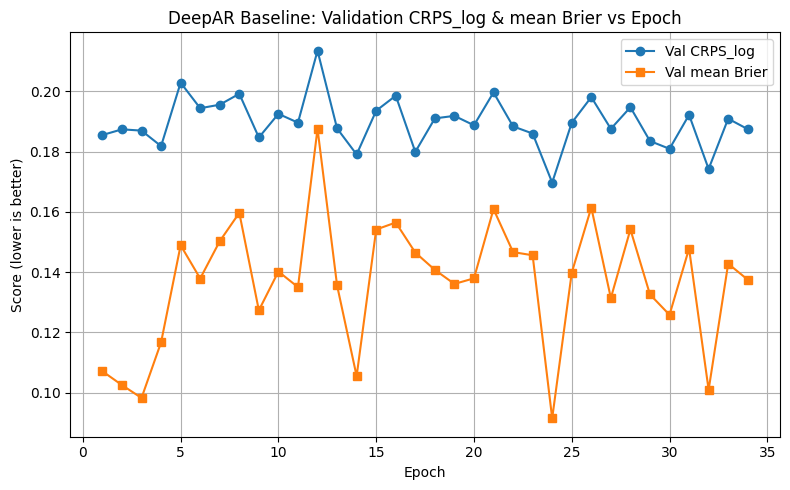

In [9]:
# ============================================================
# True DeepAR Baseline — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class for DeepAR
#    - DeepAR model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Path where final model + logs were saved
FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/DeepAR/Final_Run/v2"
print("Final run artifacts directory:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities & Metrics
# ============================================================

class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing (FULL GRID)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "rain_idx": rain_idx,
    }

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 3) Dataset
# ============================================================

class TrueDeepARDataset(Dataset):
    def __init__(
        self, X_scaled, M_in, time_feats, Y_rain, M_y,
        Acc24, MaskAcc24, season_ids, thr3h, thrAcc24,
        t_start, t_end, rain_idx, T_in=16, H_out=8
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.rain_idx = rain_idx
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min = H_out // 2

        self.indices = []
        for t in range(t_start + T_in - 1, t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]
        x_all = np.concatenate([np.nan_to_num(x, nan=0.0), m, tf], axis=-1).astype(np.float32)

        raw_rain_ctx = self.Y_rain[t-self.T_in+1:t+1]
        x_log_rain = np.log1p(np.nan_to_num(raw_rain_ctx, nan=0.0)).astype(np.float32)
        m_in_rain = self.M_in[t-self.T_in+1:t+1, :, self.rain_idx].astype(np.float32)

        tf_future = self.time_feats[t+1:t+1+self.H_out].astype(np.float32)

        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y_win, nan=0.0)).astype(np.float32)
        y_log_last = np.log1p(np.nan_to_num(self.Y_rain[t], nan=0.0)).astype(np.float32)

        flash = ((self.Y_rain[t+1] >= self.thr3h) & (self.M_y[t+1] > 0.5)).astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min).astype(np.float32)

        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)

        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)
        acc24 = ((self.Acc24[t] >= self.thrAcc24) & (self.MaskAcc24[t] > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),
            torch.from_numpy(x_log_rain), torch.from_numpy(m_in_rain),
            torch.from_numpy(tf_future),
            torch.from_numpy(y_log_last),
            torch.tensor(int(self.season_ids[t]), dtype=torch.long),
            torch.from_numpy(y_log), torch.from_numpy(m_win),
            torch.from_numpy(flash), torch.from_numpy(self.M_y[t+1].astype(np.float32)),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24), torch.from_numpy(self.MaskAcc24[t].astype(np.float32))
        )

# ============================================================
# 4) Model
# ============================================================

class TrueDeepAR(nn.Module):
    def __init__(self, num_stations, in_features, time_feat_dim, T_in, H_out, num_seasons, quantiles, d_model=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.N, self.T_in, self.H_out = num_stations, T_in, H_out
        self.quantiles = torch.tensor(quantiles, dtype=torch.float32, device=device)
        self.K = len(quantiles)
        self.d_model = d_model

        self.station_embedding = nn.Embedding(num_stations, 16)
        self.regime_embedding = nn.Embedding(num_seasons, 16)

        enc_in_dim = in_features + 16
        self.encoder = nn.LSTM(enc_in_dim, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        dec_in_dim = 1 + time_feat_dim + 16 + 16
        self.decoder_input_proj = nn.Linear(dec_in_dim, d_model)
        self.decoder = nn.LSTM(d_model, d_model, num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0)

        self.mu_head = nn.Linear(d_model, 1)
        self.sigma_head = nn.Linear(d_model, 1)

        self.flash_head = nn.Linear(d_model * 2 + 16, 1)
        self.peak_head  = nn.Linear(d_model * 2 + 16, 1)
        self.acc_head   = nn.Linear(d_model * 2 + 16, 1)

    def forward(self, x, x_log_rain, m_in_rain, tf_future, y_log_last, regime_id, y_future=None, is_training=False):
        B, T, N, F_in = x.shape

        num_valid = m_in_rain.sum(dim=1).clamp_min(1.0)
        v_i = 1.0 + (x_log_rain * m_in_rain).sum(dim=1) / num_valid
        v_i_flat = v_i.reshape(B*N, 1)

        station_ids = torch.arange(N, device=x.device).unsqueeze(0).expand(B, N).reshape(B*N)
        stat_emb = self.station_embedding(station_ids)
        reg_emb = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1).reshape(B*N, 16)

        x_flat = x.permute(0, 2, 1, 3).reshape(B*N, T, F_in)
        stat_emb_expanded = stat_emb.unsqueeze(1).expand(-1, T, -1)
        enc_in = torch.cat([x_flat, stat_emb_expanded], dim=-1)

        enc_out, (h_n, c_n) = self.encoder(enc_in)
        last_enc_hidden = enc_out[:, -1, :]

        tf_future_flat = tf_future.permute(0, 2, 1, 3).reshape(B*N, self.H_out, -1)

        # Testing script forces is_training=False for MC Sampling
        if is_training:
            pass
        else:
            S = 50
            h_n = h_n.repeat_interleave(S, dim=1)
            c_n = c_n.repeat_interleave(S, dim=1)

            dec_in_rain = (y_log_last.reshape(B*N, 1) / v_i_flat).repeat_interleave(S, dim=0)
            tf_future_flat = tf_future_flat.repeat_interleave(S, dim=0)
            stat_emb_S = stat_emb.repeat_interleave(S, dim=0)
            reg_emb_S = reg_emb.repeat_interleave(S, dim=0)
            v_i_expanded = v_i_flat.repeat_interleave(S, dim=0)

            decoder_states, paths_scaled = [], []

            for h in range(self.H_out):
                dec_in = torch.cat([dec_in_rain, tf_future_flat[:, h, :], stat_emb_S, reg_emb_S], dim=-1)
                dec_in = self.decoder_input_proj(dec_in).unsqueeze(1)

                dec_out, (h_n, c_n) = self.decoder(dec_in, (h_n, c_n))
                dec_state = dec_out.squeeze(1)
                decoder_states.append(dec_state)

                mu_scaled = self.mu_head(dec_state)
                sigma_scaled = F.softplus(self.sigma_head(dec_state)) + 1e-6

                sample_scaled = Normal(mu_scaled, sigma_scaled).rsample()
                dec_in_rain = sample_scaled
                paths_scaled.append(sample_scaled)

            paths_unscaled = torch.cat(paths_scaled, dim=1) * v_i_expanded
            paths_reshaped = paths_unscaled.reshape(B*N, S, self.H_out)

            q_hat = torch.quantile(paths_reshaped, self.quantiles, dim=1)
            q_hat = q_hat.permute(1, 2, 0).reshape(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

            avg_dec_state = torch.stack(decoder_states, dim=1).mean(dim=1)
            avg_dec_state = avg_dec_state.reshape(B*N, S, -1).mean(dim=1)

            context = torch.cat([last_enc_hidden, avg_dec_state, stat_emb], dim=-1).reshape(B, N, -1)

            flash_logits = self.flash_head(context).squeeze(-1)
            peak_logits  = self.peak_head(context).squeeze(-1)
            acc_logits   = self.acc_head(context).squeeze(-1)

            return None, None, q_hat, flash_logits, peak_logits, acc_logits


# ============================================================
# 5) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_sder = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, x_log, m_log, tf_f, y_last, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, x_log, m_log, tf_f = x.to(device), x_log.to(device), m_log.to(device), tf_f.to(device)
        y_last, reg, y_log, my = y_last.to(device), reg.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        _, _, q_hat, f_log, p_log, a_log = model(x, x_log, m_log, tf_f, y_last, reg, y_future=None, is_training=False)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(f_log)
        p_peak  = torch.sigmoid(p_log)
        p_acc   = torch.sigmoid(a_log)

        total_brier_sder += brier_score(p_flash, flash, mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_SDER": total_brier_sder / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()
    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()
    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["SDER_metrics"]   = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 6) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================
if __name__ == "__main__":

    # Ensure this matches the EXACT path where your training script saved the model
    CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
    LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

    print("Checkpoint path:", CKPT_PATH)
    print("Log path       :", LOG_PATH)

    # ---- 6.1 Load checkpoint + hparams ----
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

    hp = ckpt["hparams"]            # dict of best hyperparameters
    state_dict = ckpt["state_dict"] # model weights

    print("\nLoaded checkpoint:")
    print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
    print(f"  best_epoch       : {ckpt['best_epoch']}")

    # ---- 6.2 Extract Frozen Train-Set Statistics (PREVENTS DATA LEAKAGE) ----
    saved_mean = ckpt["scaler_mean"]
    saved_std = ckpt["scaler_std"]
    thr3h_saved = ckpt["thr3h"]
    thrAcc24_saved = ckpt["thrAcc24"]

    # ---- 6.3 Rebuild preprocessing + TEST dataset ----
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    # Time splits
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

    print("\nSplit:")
    print("  Train: 0 →", train_end)
    print("  Val:  ", train_end, "→", val_end)
    print("  Test: ", val_end, "→", T)

    # --- APPLY FROZEN SCALER ---
    X_flat = prep["X_raw"].reshape(T*N, prep["X_raw"].shape[-1])
    scaler = NaNIgnoringStandardScaler()
    # Manually inject the saved parameters to guarantee no validation/test leakage
    scaler.mean_ = saved_mean
    scaler.std_ = saved_std

    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, prep["X_raw"].shape[-1]).astype(np.float32)

    # --- APPLY FROZEN THRESHOLDS ---
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

    # Build TEST dataset using the saved thresholds
    ds_test = TrueDeepARDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h_saved, thrAcc24_saved,  # Using the frozen thresholds!
        t_start=val_end, t_end=T,
        rain_idx=prep["rain_idx"],
        T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
    )

    test_loader = DataLoader(ds_test,
                             batch_size=int(hp["batch_size"]),
                             shuffle=False)

    print("Test dataset size:", len(ds_test))

    # Infer input feature dim from one batch
    x0, *_ = next(iter(test_loader))
    F_in = x0.shape[-1]
    print("Input feature dim:", F_in)

    # ---- 6.4 Rebuild model and load weights ----
    model = TrueDeepAR(
        num_stations=N,
        in_features=F_in,
        time_feat_dim=4,
        T_in=int(hp["T_in"]),
        H_out=int(hp["H_out"]),
        num_seasons=len(prep["unique_seasons"]),
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
        d_model=int(hp["d_model"]),
        num_layers=int(hp["num_layers"]),
        dropout=float(hp["dropout"]),
    ).to(device)

    model.load_state_dict(state_dict)
    model.eval()

    print("\nModel rebuilt and weights loaded.")

    # ---- 6.5 Evaluate on TEST set ----
    with torch.no_grad():
        test_scores = evaluate(
            model,
            test_loader,
            quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
            device=device,
        )

    print("\n========== TEST METRICS ==========")
    print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
    print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
    print(f"Brier_SDER : {test_scores['Brier_SDER']:.4f}")
    print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
    print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

    # Print MAE and RMSE
    maes = test_scores["MAE_mm_by_lead"]
    rmses = test_scores["RMSE_mm_by_lead"]
    print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
    print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
    print(f"(MAE per 3h step: {maes})")
    print(f"(RMSE per 3h step: {rmses})")

    # Print CSI, POD, FAR
    target_thr = 0.5

    fm = test_scores["SDER_metrics"]
    pm = test_scores["Peak24_metrics"]
    am = test_scores["Acc24_metrics"]

    def print_event_metrics(name, metrics, thr):
        print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
        if thr in metrics["by_thr"]:
            m = metrics["by_thr"][thr]
            print(f"  @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
        else:
            print(f"  @Thr={thr}: Metrics not found")

    print_event_metrics("SDER 3h", fm, target_thr)
    print_event_metrics("Peak 24h", pm, target_thr)
    print_event_metrics("Acc 24h",  am, target_thr)

    # ---- 6.6 Plot learning curves from final_epoch_log.csv ----
    if os.path.exists(LOG_PATH):
        log_df = pd.read_csv(LOG_PATH)
        print("\nLoaded epoch log with {} rows.".format(len(log_df)))

        log_df["mean_brier"] = log_df[["val_Brier_flash", "val_Brier_peak", "val_Brier_acc"]].mean(axis=1)

        plt.figure(figsize=(8, 5))
        plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
        plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
        plt.xlabel("Epoch")
        plt.ylabel("Score (lower is better)")
        plt.title("DeepAR Baseline: Validation CRPS_log & mean Brier vs Epoch")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nWarning: Could not find log file at {LOG_PATH} for plotting.")